<a href="https://colab.research.google.com/github/perbik/cttc-data-science/blob/main/CTTC_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Python Scripts: Cleaning, Visualization, & Analysis**

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("messy_sales.csv")
df.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32,USD 858,########,10%
1,1/30/2024,north,Tablet,Electronics,72,$833.83,########,15 percent
2,2/13/2024,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,4/28/2024,West,Laptop,gadget,thirty,$733.46,########,0.1
4,2/18/2024,EAST,Phone,ELEC,47,USD 373,"40,920",0.1
5,April 03 2024,South,laptop,Gadgets,twenty,670.28,3103,8 percent
6,1/28/2024,north,tablet,electronics,thirty,758.58,"37,789",8 percent
7,March 15 2024,West,Tablet,Gadgets,47,$241.65,"11,484",12%
8,January 09 2024,West,Phone,gadget,thirty,USD 796,"18,486",8 percent
9,2/7/2024,West,laptop,Gadgets,thirty,$996.92,"20,558",0.08


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               200 non-null    object
 1   Region             200 non-null    object
 2   Product            200 non-null    object
 3   Category           200 non-null    object
 4   Units Sold         196 non-null    object
 5   Unit Price         200 non-null    object
 6   Total Sales        197 non-null    object
 7   Profit Margin (%)  200 non-null    object
dtypes: object(8)
memory usage: 12.6+ KB


In [6]:
df.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,4
Unit Price,0
Total Sales,3
Profit Margin (%),0


In [7]:
df['Units Sold'] = pd.to_numeric(df['Units Sold'], errors='coerce')
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce')

In [8]:
df['Units Sold'] = df['Units Sold'].fillna(df["Units Sold"].mean())
df['Total Sales'] = df['Total Sales'].fillna(df["Total Sales"].mean())

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df['Date'] = pd.to_datetime(df["Date"], errors = "coerce")

In [11]:
for col in ['Region', 'Product', 'Category']:
  df[col] = df[col].str.strip().str.title()

In [12]:
df['Units Sold'] = pd.to_numeric(df['Units Sold'], errors='coerce')

In [13]:
for col in ['Unit Price', 'Total Sales']:
  df[col] = df[col].astype(str)
  df[col] = (
      df[col]
        .str.replace("[$, USD]", "", regex=True)
        .str.strip()
  )
  df[col] = pd.to_numeric(df[col], errors = "coerce")

In [14]:
df['Profit Margin (%)'] = (
    df['Profit Margin (%)']
      .astype(str)
      .str.replace("%", "", regex=True)
      .str.replace("percent", "", regex=True)
      .astype(float)
)
df['Profit Margin (%)'] = np.where(df['Profit Margin (%)'] < 1, df['Profit Margin (%)'] * 100, df['Profit Margin (%)'])

In [15]:
for col in ['Category']:
  df[col] = df[col].replace('Elec', 'Electronics')
  df[col] = df[col].replace('Gadget', 'Gadgets')

In [16]:
df_cleaned = df.dropna(subset = ['Date', 'Total Sales', 'Region'])

In [17]:
df_cleaned.head(15)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26096.323077,10.0
5,2024-04-03,South,Laptop,Gadgets,52.307692,670.28,3103.000000,8.0
7,2024-03-15,West,Tablet,Gadgets,47.000000,241.65,26096.323077,12.0
8,2024-01-09,West,Phone,Gadgets,52.307692,796.00,26096.323077,8.0
10,2024-01-26,South,Desktop,Electronics,52.307692,100.76,26096.323077,8.0
12,2024-04-06,North,Tablet,Electronics,52.307692,548.00,26096.323077,8.0
14,2024-03-03,South,Tablet,Electronics,52.307692,348.60,7352.000000,8.0
18,2024-03-03,South,Laptop,Electronics,28.000000,655.07,26096.323077,8.0
23,2024-01-20,East,Desktop,Gadgets,52.307692,803.81,26096.323077,15.0
25,2024-04-25,South,Tablet,Electronics,52.307692,540.16,26096.323077,10.0


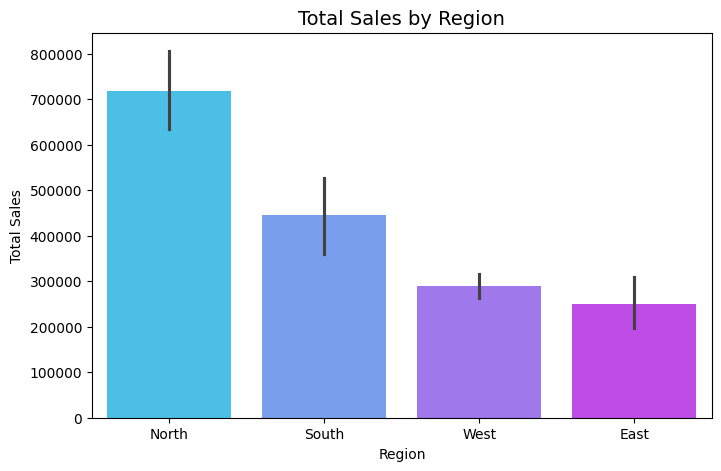

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_cleaned, x='Region', y='Total Sales', estimator=sum, palette='cool')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

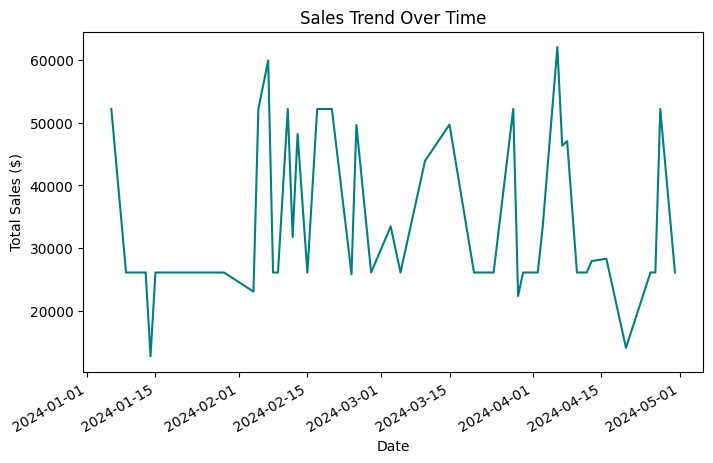

In [19]:
plt.figure(figsize=(8,5))
df_cleaned.groupby('Date')['Total Sales'].sum().plot(kind='line', color='teal')
plt.title('Sales Trend Over Time')
plt.ylabel('Total Sales ($)')
plt.show()

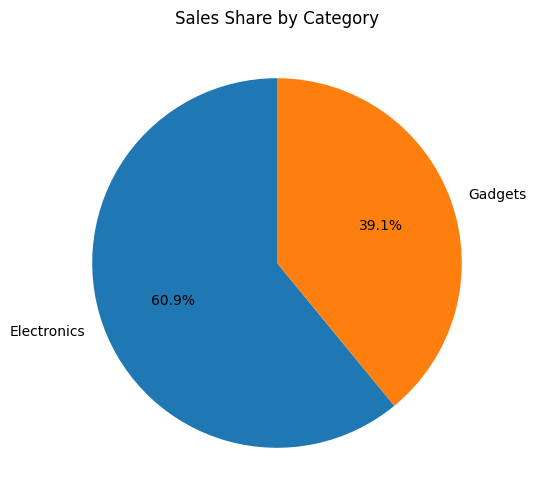

In [20]:
plt.figure(figsize=(6,6))
category_sales = df_cleaned.groupby('Category')['Total Sales'].sum()
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Sales Share by Category")
plt.ylabel('')
plt.show()